#Applying Machine Learning To Sentiment Analysis

## Obtaining the IMDb movie review dataset

The IMDB movie review set can be downloaded from [http://ai.stanford.edu/~amaas/data/sentiment/](http://ai.stanford.edu/~amaas/data/sentiment/).
After downloading the dataset, decompress the files.



In [1]:
import os
import sys
import tarfile
import time
import urllib.request

source = 'http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz'
target = 'Imdb.tar.gz'

if os.path.exists(target):
    os.remove(target)


if not os.path.isdir('Imdb') and not os.path.isfile('Imdb.tar.gz'):
    urllib.request.urlretrieve(source, target)

In [2]:
if not os.path.isdir('Imdb'):

    with tarfile.open(target, 'r:gz') as tar:
        tar.extractall()

/tmp/ipykernel_570/4060774916.py:4: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


## Preprocessing the movie dataset into more convenient format

In [3]:
!pip install pyprind

In [4]:
import pyprind
import pandas as pd
import os
import sys
from packaging import version


basepath = 'aclImdb'

labels = {'pos': 1, 'neg': 0}

pbar = pyprind.ProgBar(50000, stream=2)

df = pd.DataFrame()
for s in ('test', 'train'):
    for l in ('pos', 'neg'):
        path = os.path.join(basepath, s, l)
        for file in sorted(os.listdir(path)):
            with open(os.path.join(path, file),
                      'r', encoding='utf-8') as infile:
                txt = infile.read()

            if version.parse(pd.__version__) >= version.parse("1.3.2"):
                x = pd.DataFrame([[txt, labels[l]]], columns=['review', 'sentiment'])
                df = pd.concat([df, x], ignore_index=False)

            else:
                df = df.append([[txt, labels[l]]],
                               ignore_index=True)
            pbar.update()
df.columns = ['review', 'sentiment']

0% [##############################] 100% | ETA: 00:00:00
Total time elapsed: 00:01:45


Shuffling the DataFrame:

In [5]:
import numpy as np

np.random.seed(0)
df = df.reindex(np.random.permutation(df.index))

 Saving the assembled data as CSV file:

In [6]:
df.to_csv('movie_data.csv', index=False, encoding='utf-8')

In [7]:
import pandas as pd

df = pd.read_csv('movie_data.csv', encoding='utf-8')

# the following is necessary on some computers:
df = df.rename(columns={"0": "review", "1": "sentiment"})

df.head(3)

,review,sentiment
0,I went and saw this movie last night after bei...,1
1,Actor turned director Bill Paxton follows up h...,1
2,As a recreational golfer with some knowledge o...,1


In [8]:
df.shape

(50000, 2)

# bag-of-words model

In [9]:
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer
# this is just an example
count = CountVectorizer()
docs = np.array([
        'The sun is shining',
        'The weather is sweet',
        'The sun is shining, the weather is sweet, and one and one is two'])
bag = count.fit_transform(docs)

In [10]:
print(count.vocabulary_)

{'the': 6, 'sun': 4, 'is': 1, 'shining': 3, 'weather': 8, 'sweet': 5, 'and': 0, 'one': 2, 'two': 7}


In [11]:
print(bag.toarray())

[[0 1 0 1 1 0 1 0 0]
 [0 1 0 0 0 1 1 0 1]
 [2 3 2 1 1 1 2 1 1]]


## Assessing word relevancy via term frequency-inverse document frequency

In [12]:
np.set_printoptions(precision=2)

In [13]:
from sklearn.feature_extraction.text import TfidfTransformer
# some words are found in all docs so they dont have discriminatory info and through tfidf we reduce their weight
tfidf = TfidfTransformer(use_idf=True,
                         norm='l2',
                         smooth_idf=True)
print(tfidf.fit_transform(count.fit_transform(docs))
      .toarray())

[[0.   0.43 0.   0.56 0.56 0.   0.43 0.   0.  ]
 [0.   0.43 0.   0.   0.   0.56 0.43 0.   0.56]
 [0.5  0.45 0.5  0.19 0.19 0.19 0.3  0.25 0.19]]


## Cleaning text data

In [14]:
# as you can see it contains html tags
df.loc[2, 'review'][-500:]

'm of competing against those who think he is inferior.<br /><br />Finally, the golf scenes are well photographed. Although the course used in the movie was not the actual site of the historical tournament, the little liberties taken by Disney do not detract from the beauty of the film. There\'s one little Disney moment at the pool table; otherwise, the viewer does not really think Disney. The ending, as in "Miracle," is not some Disney creation, but one that only human history could have written.'

In [15]:
import re
# a function for removing all the html tags and exclamation marks etc except emoticons
def preprocessor(text):
    text = re.sub('<[^>]*>', '', text) #removes the html tags
    emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',  #extracts all the emoticons
                           text)
    text = (re.sub('[\W]+', ' ', text.lower()) +
            ' '.join(emoticons).replace('-', ''))  #adds everything together also removes the nose from emoticons
            # the reason we add emoticons to end is that we use 1-gram bag of words mdoel so its not a problem
    return text

<>:5: SyntaxWarning: invalid escape sequence '\)'
<>:7: SyntaxWarning: invalid escape sequence '\W'
<>:5: SyntaxWarning: invalid escape sequence '\)'
<>:7: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_570/1868749774.py:5: SyntaxWarning: invalid escape sequence '\)'
  emoticons = re.findall('(?::|;|=)(?:-)?(?:\)|\(|D|P)',  #extracts all the emoticons
/tmp/ipykernel_570/1868749774.py:7: SyntaxWarning: invalid escape sequence '\W'
  text = (re.sub('[\W]+', ' ', text.lower()) +


In [16]:
preprocessor(df.loc[2, 'review'][-500:])

'm of competing against those who think he is inferior finally the golf scenes are well photographed although the course used in the movie was not the actual site of the historical tournament the little liberties taken by disney do not detract from the beauty of the film there s one little disney moment at the pool table otherwise the viewer does not really think disney the ending as in miracle is not some disney creation but one that only human history could have written '

In [17]:
preprocessor("</a>This :) is :( a test :-)!")

'this is a test :) :( :)'

In [18]:
# the preprocessor is applied to all the reviews
df['review'] = df['review'].apply(preprocessor)

## Processing documents into tokens

In [19]:
from nltk.stem.porter import PorterStemmer

porter = PorterStemmer()
# thsi simply splits based on spaces
def tokenizer(text):
    return text.split()

# it converts each word to its base form as well
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

In [20]:
tokenizer('runners like running and thus they run')

['runners', 'like', 'running', 'and', 'thus', 'they', 'run']

In [21]:
tokenizer_porter('runners like running and thus they run')

['runner', 'like', 'run', 'and', 'thu', 'they', 'run']

In [22]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
from nltk.corpus import stopwords
# if you arent  gonna use tfidf then u should remove stopwords as tfidf already reduces their weight
stop = stopwords.words('english')
# this stop will be passed as param into gridsearch

# Training a logistic regression model for document classification using gridSearch

In [38]:
# X_train = df.loc[:25000, 'review'].values
# y_train = df.loc[:25000, 'sentiment'].values
# X_test = df.loc[25000:, 'review'].values
# y_test = df.loc[25000:, 'sentiment'].values

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentiment']
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import GridSearchCV

tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        preprocessor=None)

"""
param_grid = [{'vect__ngram_range': [(1, 1)],
               'vect__stop_words': [stop, None],
               'vect__tokenizer': [tokenizer, tokenizer_porter],
               'clf__penalty': ['l1', 'l2'],
               'clf__C': [1.0, 10.0, 100.0]},
              {'vect__ngram_range': [(1, 1)],
               'vect__stop_words': [stop, None],
               'vect__tokenizer': [tokenizer, tokenizer_porter],
               'vect__use_idf':[False],
               'vect__norm':[None],
               'clf__penalty': ['l1', 'l2'],
               'clf__C': [1.0, 10.0, 100.0]},
              ]

"""
small_param_grid = [{'vect__ngram_range': [(1, 1)],
                     'vect__stop_words': [None],
                     'vect__tokenizer': [tokenizer, tokenizer_porter],
                     'clf__penalty': ['l2'],
                     'clf__C': [1.0, 10.0]},
                    {'vect__ngram_range': [(1, 1)],
                     'vect__stop_words': [stop, None],
                     'vect__tokenizer': [tokenizer],
                     'vect__use_idf':[False], #raw freq will be used
                     'vect__norm':[None],
                     'clf__penalty': ['l2'],
                  'clf__C': [1.0, 10.0]},
              ]


lr_tfidf = Pipeline([('vect', tfidf),
                     ('clf', LogisticRegression(solver='liblinear'))])

gs_lr_tfidf = GridSearchCV(lr_tfidf, small_param_grid,
                           scoring='accuracy',
                           cv=5,
                           verbose=2,
                           n_jobs=-1)

In [26]:
gs_lr_tfidf.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vect',
                                        TfidfVectorizer(lowercase=False)),
                                       ('clf',
                                        LogisticRegression(solver='liblinear'))]),
             n_jobs=-1,
             param_grid=[{'clf__C': [1.0, 10.0], 'clf__penalty': ['l2'],
                          'vect__ngram_range': [(1, 1)],
                          'vect__stop_words': [None],
                          'vect__tokenizer': [<function tokenizer at 0x7d4e106374c0>,
                                              <function tokenizer_porter at 0x7d4e10637100...
                          'vect__stop_words': [['a', 'about', 'above', 'after',
                                                'again', 'against', 'ain',
                                                'all', 'am', 'an', 'and', 'any',
                                                'are', 'aren', "aren't", 'as',
                                                'at', 'be', 'because', 'been',
                                                'before', 'being', 'below',
                                                'between', 'both', 'but', 'by',
                                                'can', 'couldn', "couldn't", ...],
                                               None],
                          'vect__tokenizer': [<function tokenizer at 0x7d4e106374c0>],
                          'vect__use_idf': [False]}],
             scoring='accuracy', verbose=2)

In [27]:
print(f'Best parameter set: {gs_lr_tfidf.best_params_}')
print(f'CV Accuracy: {gs_lr_tfidf.best_score_:.3f}')

Best parameter set: {'clf__C': 10.0, 'clf__penalty': 'l2', 'vect__ngram_range': (1, 1), 'vect__stop_words': None, 'vect__tokenizer': <function tokenizer at 0x7d4e106374c0>}
CV Accuracy: 0.900


In [28]:
clf = gs_lr_tfidf.best_estimator_
print(f'Test Accuracy: {clf.score(X_test, y_test):.3f}')

Test Accuracy: 0.907


In [29]:
import joblib

joblib.dump(clf, 'sentiment_model.pkl')

['sentiment_model.pkl']

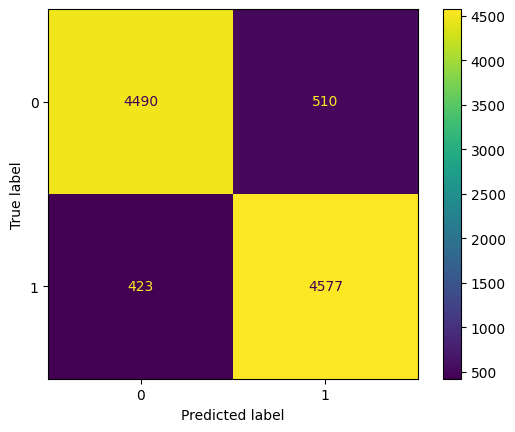

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.show()

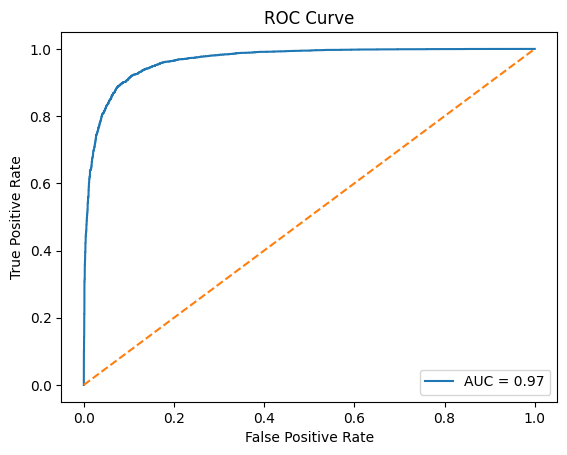

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [33]:
import numpy as np

feature_names = clf.named_steps['vect'].get_feature_names_out()
coefs = clf.named_steps['clf'].coef_[0]
# top positive and top negative words
top_positive = np.argsort(coefs)[-10:]
top_negative = np.argsort(coefs)[:10]

print("Positive words:")
print([feature_names[i] for i in top_positive])

print("\nNegative words:")
print([feature_names[i] for i in top_negative])

Positive words:
['loved', 'amazing', 'wonderful', 'best', 'hilarious', '8', 'perfect', 'great', '7', 'excellent']

Negative words:
['worst', 'waste', 'awful', 'boring', 'terrible', 'bad', 'disappointment', 'poor', 'dull', 'fails']


In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8997444466286613
Recall: 0.9154
F1 Score: 0.9075047090314265
